# Train — fox policy (behavioural cloning, no memory)

Clone the **fox** RuleBrain into a small memoryless network:

```
grids (C,K,K) ─CNN─┐
                   ├─▶ trunk (MLP) ─▶ heading mean (2)  ─ MSE  ─▶ teacher heading
scalars (10) ─MLP──┘                 gate logits  (3)  ─ BCE  ─▶ eat / drink / repro
                                     speed logit  (1)  ─ BCE  ─▶ speed throttle
```

Same CNN front-end as the deployed brain (`sim/neural_brain.py`), but the LSTM is replaced
by a feed-forward trunk and the critic is dropped — this is supervised imitation, not RL.
We **hold out one whole world** for validation, so the reported metrics measure
generalization to a map the network never trained on.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, _cwd / "notebooks" / "imitation_learning"):
    if (_c / "common.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import common as C
from config import SHEEP, FOX, SPECIES_NAMES

SID = FOX
device = "cuda" if torch.cuda.is_available() else "cpu"
print("species:", SPECIES_NAMES[SID], "| device:", device,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

species: fox | device: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## Load the dataset

Grids stay **float16** in CPU RAM; each minibatch is sliced and moved to the GPU as float32,
so the whole dataset never has to fit in VRAM at once.

In [2]:
d = C.load_dataset(SID)
print("rows:", d['grids'].shape[0], "| grids:", d['grids'].shape[1:],
      "| worlds:", np.bincount(d['world']))
VAL_WORLD = int(d['world'].max())        # held-out validation world (last collected)

rows: 18000 | grids: (4, 57, 57) | worlds: [3000 3000 3000 3000 3000 3000]


## Train

GPU-batched behavioural cloning. Watch `val cos` (heading cosine vs the teacher, →1 is
perfect) and the per-gate accuracies climb on the held-out world.

In [3]:
model, history = C.train_policy(SID, d, device=device, epochs=25,
                               batch_size=512, lr=1e-3, val_world=VAL_WORLD)

  gate +rates [0.08 0.22 0.19] speed +rate 0.68 -> pos_weight gates [11.7  3.6  4.2] speed 0.5


  [fox  1/25] loss=2.3593 (head=0.9865 gate=1.1543 speed=0.4369) | val cos=-0.126 eat=0.43 drink=0.38 repro=0.39 speed=0.44


  [fox  2/25] loss=2.2390 (head=0.9695 gate=1.0664 speed=0.4063) | val cos=-0.010 eat=0.52 drink=0.62 repro=0.51 speed=0.41


  [fox  3/25] loss=2.0823 (head=0.9473 gate=0.9521 speed=0.3658) | val cos=-0.018 eat=0.75 drink=0.66 repro=0.61 speed=0.49


  [fox  4/25] loss=1.9488 (head=0.9201 gate=0.8668 speed=0.3237) | val cos=-0.024 eat=0.58 drink=0.73 repro=0.61 speed=0.57


...

  [fox 21/25] loss=1.1079 (head=0.7300 gate=0.3292 speed=0.0974) | val cos=0.129 eat=0.71 drink=0.78 repro=0.73 speed=0.78


  [fox 22/25] loss=1.0602 (head=0.7039 gate=0.3100 speed=0.0925) | val cos=0.124 eat=0.76 drink=0.79 repro=0.76 speed=0.77


  [fox 23/25] loss=1.0325 (head=0.6923 gate=0.2965 speed=0.0873) | val cos=0.092 eat=0.78 drink=0.79 repro=0.74 speed=0.78


  [fox 24/25] loss=1.0260 (head=0.6925 gate=0.2913 speed=0.0846) | val cos=0.097 eat=0.80 drink=0.79 repro=0.75 speed=0.79


  [fox 25/25] loss=1.0199 (head=0.6924 gate=0.2848 speed=0.0854) | val cos=0.060 eat=0.78 drink=0.78 repro=0.74 speed=0.79


## Results

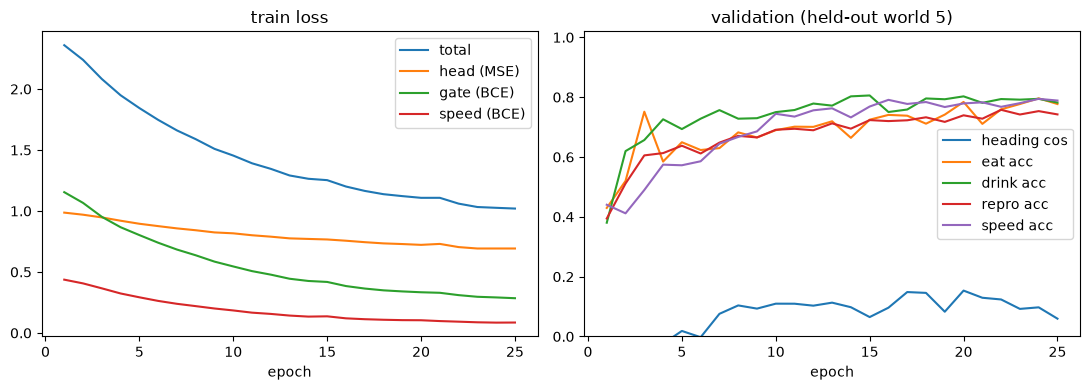

{'heading_cos': 0.06, 'eat_acc': 0.777, 'drink_acc': 0.782, 'repro_acc': 0.742, 'speed_acc': 0.789}


In [4]:
ep = [h['epoch'] for h in history]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['tr_loss'] for h in history], label='total')
ax[0].plot(ep, [h['tr_head'] for h in history], label='head (MSE)')
ax[0].plot(ep, [h['tr_gate'] for h in history], label='gate (BCE)')
ax[0].plot(ep, [h['tr_speed'] for h in history], label='speed (BCE)')
ax[0].set_title('train loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(ep, [h['heading_cos'] for h in history], label='heading cos')
ax[1].plot(ep, [h['eat_acc'] for h in history], label='eat acc')
ax[1].plot(ep, [h['drink_acc'] for h in history], label='drink acc')
ax[1].plot(ep, [h['repro_acc'] for h in history], label='repro acc')
ax[1].plot(ep, [h['speed_acc'] for h in history], label='speed acc')
ax[1].set_title(f'validation (held-out world {VAL_WORLD})')
ax[1].set_xlabel('epoch'); ax[1].set_ylim(0, 1.02); ax[1].legend()
plt.tight_layout(); plt.show()

final = history[-1]
print({k: round(final[k], 3) for k in ('heading_cos','eat_acc','drink_acc','repro_acc','speed_acc')})

## Save the model

In [5]:
path = C.save_model(SID, model, meta={'epochs': len(history),
                                          'val_world': VAL_WORLD,
                                          'final': history[-1]})
print("saved ->", path)

saved -> C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\fox.pt
